In [19]:
import pandas as pd
import matplotlib.pyplot as plt

def view_data(file_path):
    # Read the data from the specified file path
    data = pd.read_csv(file_path)

    
    return data

file_path = "//Projetos2/Wrk/SIM-DATASUS/MICRODADOS/SIM-DATASUS-2020.csv"

data = view_data(file_path)

dictionary_colors = {
    'estado_civil': {'1': 'red', '2': 'blue', '3': 'green', '4': 'orange', '5': 'purple'},
    'sexo': {'1': 'cyan', '2': 'magenta'},
    'escolaridade': {'1': 'yellow', '2': 'brown', '3': 'pink', '4': 'gray', '5': 'olive'},
    'raca_cor': {'1': 'darkgreen', '2': 'navy', '3': 'yellow', '4': 'maroon', '5': 'red'}
}

dictionary_labels = {
    'estado_civil': {'1': 'Solteiro(a)', '2': 'Casado(a)', '3': 'Viúvo(a)', '4': 'Divorciado(a)', '5': 'União Consensual'},
    'sexo': {'1': 'Masculino', '2': 'Feminino'},
    'escolaridade': {'1': 'Nenhuma', '2': '1 a 3 anos', '3': '4 a 7 anos', '4': '8 a 11 anos', '5': '12 anos ou mais'},
    'raca_cor': {'1': 'Branca', '2': 'Preta', '3': 'Amarela', '4': 'Parda', '5': 'Indígena'}
}

def plot_data(df, x, y, kind='line', title=None, xlabel=None, ylabel=None, color=None, figsize=(10, 6)):
    """
    A generalist wrapper for matplotlib/pandas plotting.
    
    Parameters:
    - df: Pandas DataFrame
    - x: Column name for x-axis
    - y: Column name for y-axis (or list of names)
    - kind: 'line', 'bar', 'scatter', 'hist'
    """
    plt.figure(figsize=figsize)
    
    # Map 'kind' to specific matplotlib logic if necessary
    if kind == 'line':
        plt.plot(df[x], df[y], color=color, marker='o' if len(df) < 50 else None)
    elif kind == 'bar':
        plt.bar(df[x], df[y], color=color)
    elif kind == 'scatter':
        plt.scatter(df[x], df[y], color=color, alpha=0.6)
    
    # Customization
    plt.title(title or f'{kind.capitalize()} Plot: {y} vs {x}')
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_subsector_categories(data, subsector, dictionary_colors, dictionary_labels, kind='line', figsize=(10, 6)):
    """
    Plot each subcategory of a subsector with its respective label and color.
    
    Parameters:
    - data: Pandas DataFrame containing the data
    - subsector: String name of the subsector column (e.g., 'sexo', 'raca_cor')
    - dictionary_colors: Dict mapping subsector to dict of {subcategory_id: color}
    - dictionary_labels: Dict mapping subsector to dict of {subcategory_id: label}
    - kind: Type of plot ('line', 'bar', 'scatter')
    - figsize: Figure size tuple
    """
    # Get unique subcategories for this subsector
    subcategories = sorted(data[subsector].dropna().unique())
    
    # Get colors and labels for this subsector
    colors = dictionary_colors.get(subsector, {})
    labels = dictionary_labels.get(subsector, {})
    
    # Create a plot for each subcategory
    for subcategory in subcategories:
        subcategory_str = str(int(subcategory))
        
        # Filter data for this subcategory
        df_filtered = data[data[subsector] == subcategory].groupby('idade').size().reset_index(name='total_obitos')
        
        # Get color and label
        color = colors.get(subcategory_str, None)
        label = labels.get(subcategory_str, f'Categoria {subcategory_str}')
        
        # Plot the data
        plt.figure(figsize=figsize)
        if kind == 'line':
            plt.plot(df_filtered['idade'], df_filtered['total_obitos'], color=color, label=label, linewidth=2)
        elif kind == 'bar':
            plt.bar(df_filtered['idade'], df_filtered['total_obitos'], color=color, label=label)
        elif kind == 'scatter':
            plt.scatter(df_filtered['idade'], df_filtered['total_obitos'], color=color, label=label, s=100, alpha=0.6)
        
        plt.title(f'Total Óbitos by Idade - {subsector.capitalize()}: {label}', fontsize=14, fontweight='bold')
        plt.xlabel('Idade', fontsize=12)
        plt.ylabel('Total Óbitos', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()


# Display by subsectors ['raca_cor', 'sexo', 'escolaridade', 'estado_civil']
subsectors = ['raca_cor', 'sexo', 'escolaridade', 'estado_civil']






C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:6: DtypeWarning: Columns (57,62,74,86) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


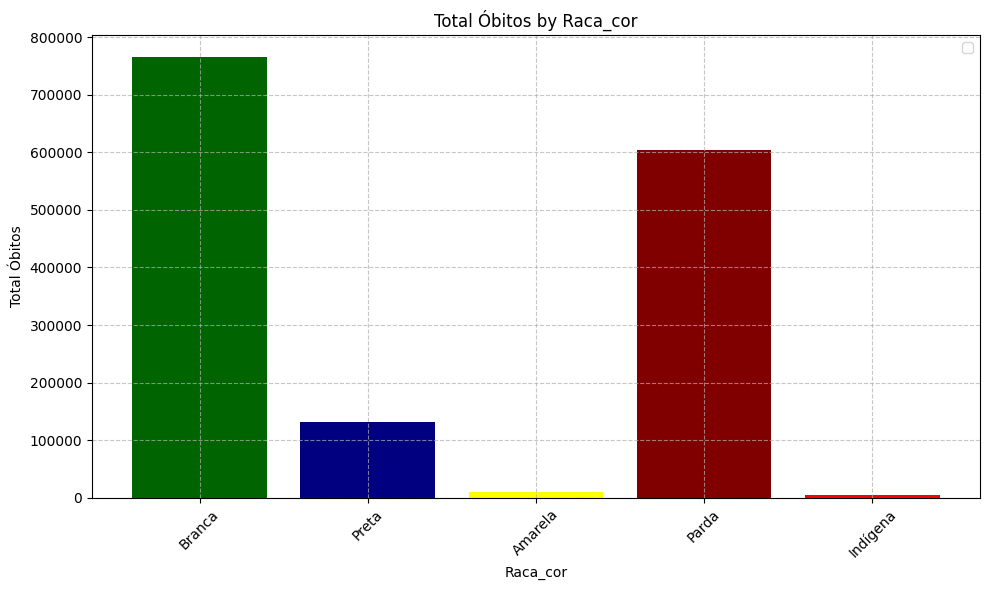

C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


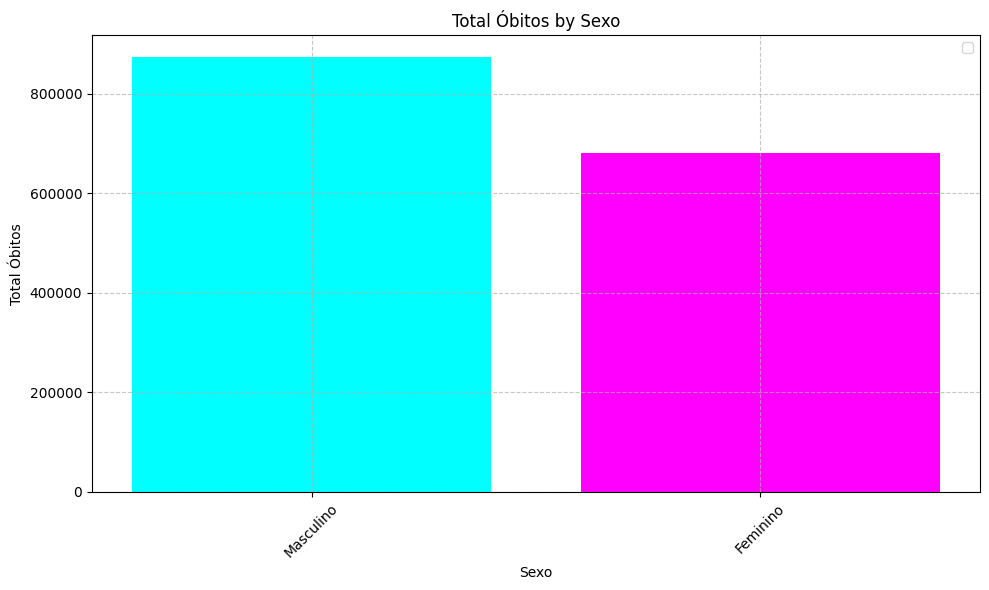

C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


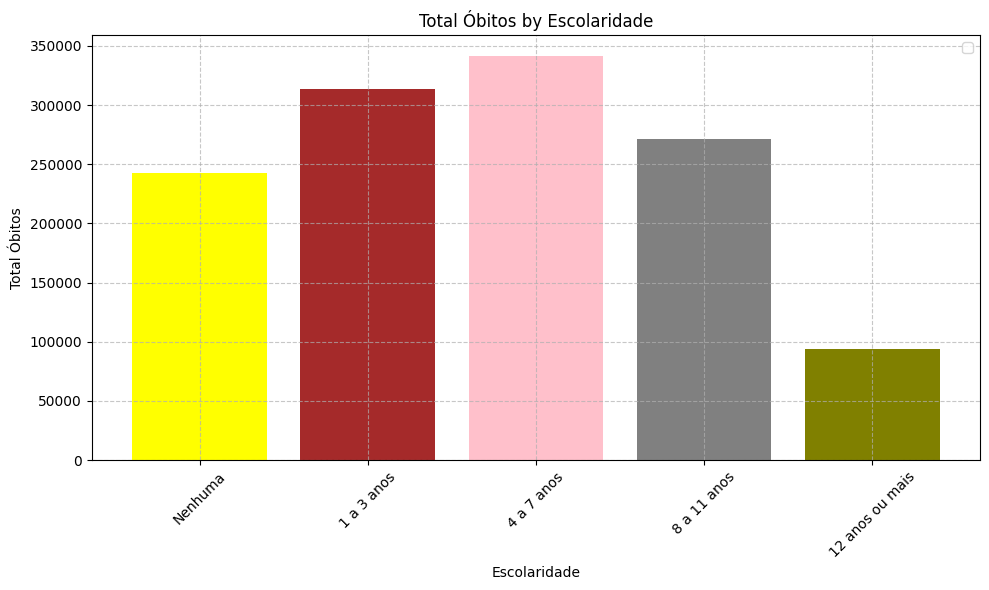

C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


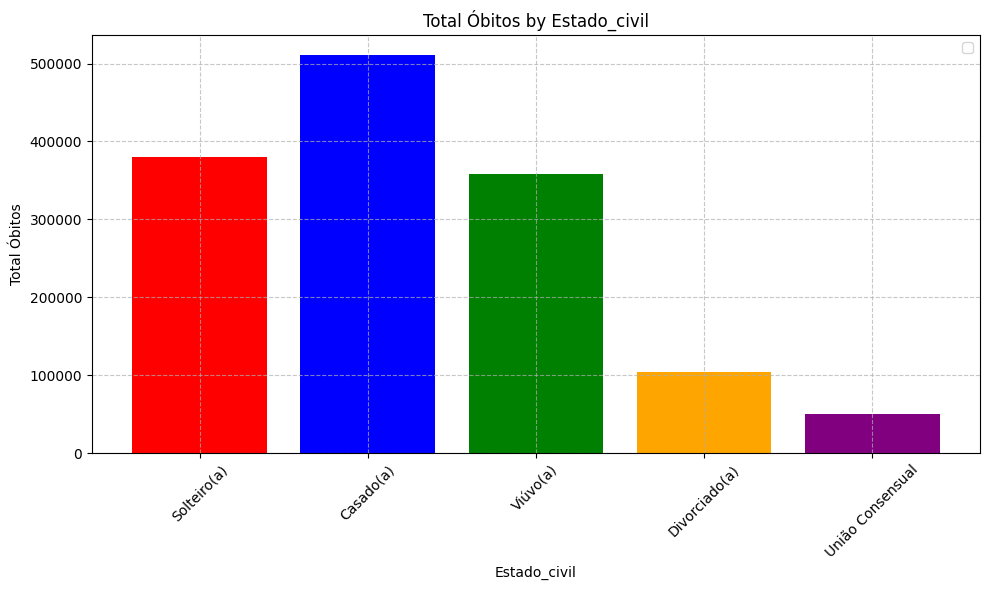

In [31]:
# Generalized function for any category
def total_deaths_by_category(data, category, dictionary_colors, dictionary_labels):
    """
    Calculate total deaths by category with labels and colors.
    
    Parameters:
    - data: Pandas DataFrame containing the data
    - category: String name of the category column (e.g., 'raca_cor', 'sexo')
    - dictionary_colors: Dict mapping category to dict of {id: color}
    - dictionary_labels: Dict mapping category to dict of {id: label}
    
    Returns:
    - DataFrame with category, total_obitos, colors, and labels
    """
    df_cat = data.groupby(category).size().reset_index(name='total_obitos')
    
    # Normalize keys to strings that match the dictionary keys.
    # Handles numeric floats like 1.0 -> '1' and preserves string keys like 'A'.
    def _normalize_key(v):
        if pd.isna(v):
            return '0'
        # float that is integer-like
        if isinstance(v, float):
            if v.is_integer():
                return str(int(v))
            return str(v)
        return str(v).strip()
    
    df_cat['cat_str'] = df_cat[category].apply(_normalize_key)
    # Map colors and labels, and ensure missing colors get a safe default
    df_cat['colors'] = df_cat['cat_str'].map(dictionary_colors.get(category, {})).fillna('gray')
    df_cat['label'] = df_cat['cat_str'].map(dictionary_labels.get(category, {}))
    
    # Remove rows with NaN labels (unmapped values)
    df_cat = df_cat.dropna(subset=['label'])
    
    return df_cat

total_deaths = {}

# Plot for every subsector
for subsector in subsectors:
    df_cat = total_deaths_by_category(data, subsector, dictionary_colors, dictionary_labels)

    total_deaths[subsector] = df_cat.set_index('label')['total_obitos'].to_dict()
    # Use the human-friendly label for the x axis and a cleaned color list (no NaN)
    plot_data(
        df_cat,
        x='label',
        y='total_obitos',
        kind='bar',
        title=f'Total Óbitos by {subsector.capitalize()}',
        xlabel=subsector.capitalize(),
        ylabel='Total Óbitos',
        color=df_cat['colors'].tolist(),
        figsize=(10, 6)
    )


C:\Users\Maia\AppData\Local\Temp\ipykernel_16648\2212196621.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


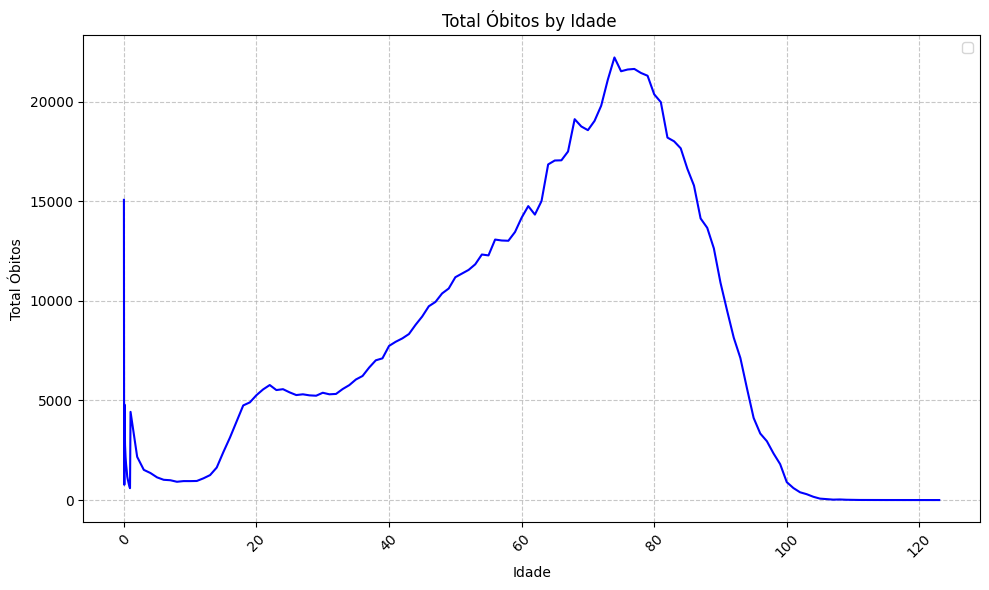

In [13]:
df_filtered = data.groupby('idade').size().reset_index(name='total_obitos')
plot_data(df_filtered, x='idade', y='total_obitos', kind='line', title=f'Total Óbitos by Idade ', xlabel='Idade', ylabel='Total Óbitos', color='blue', figsize=(10, 6))

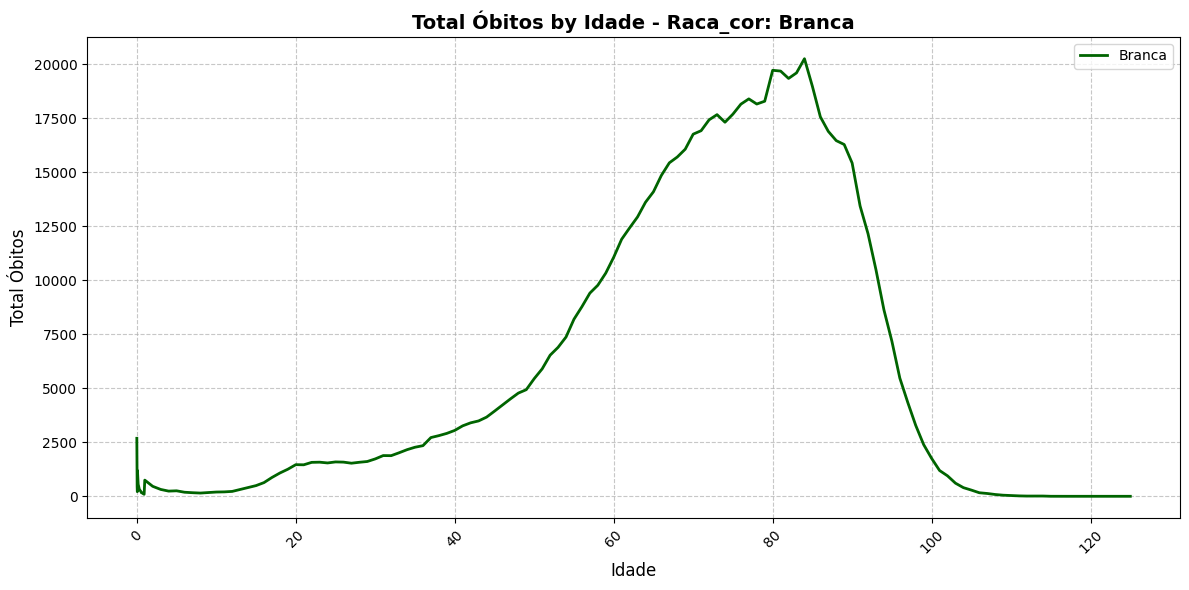

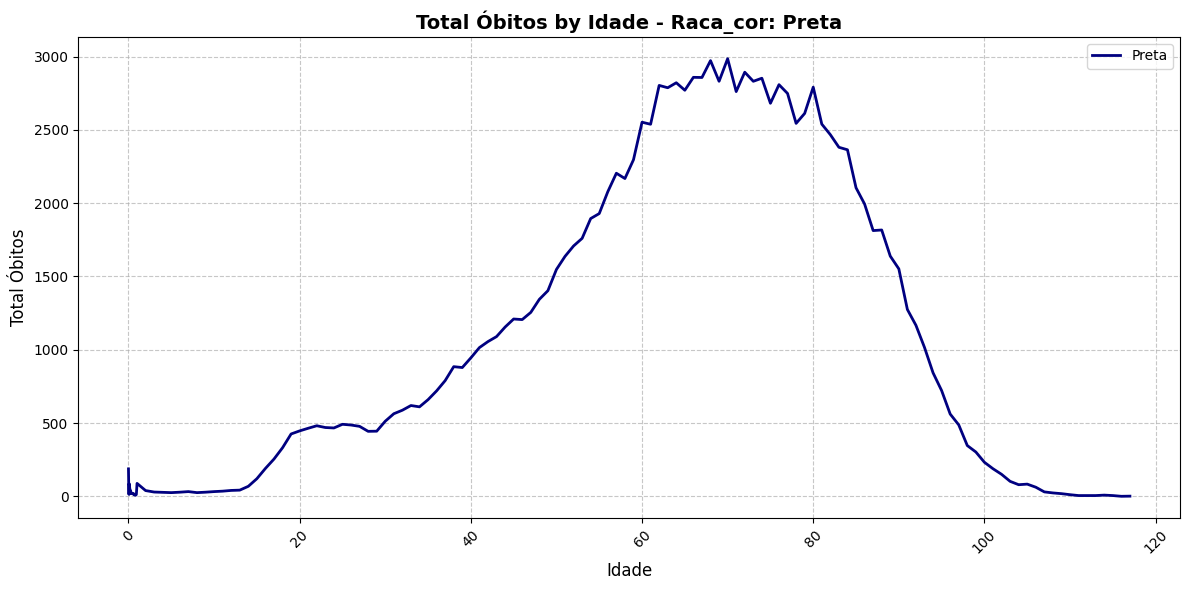

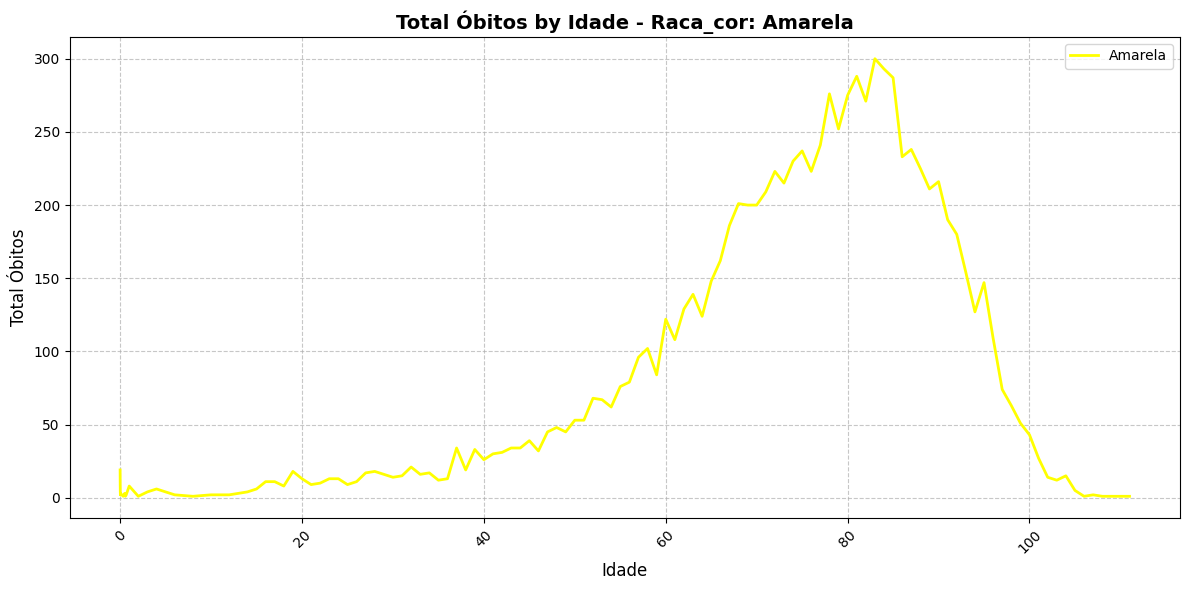

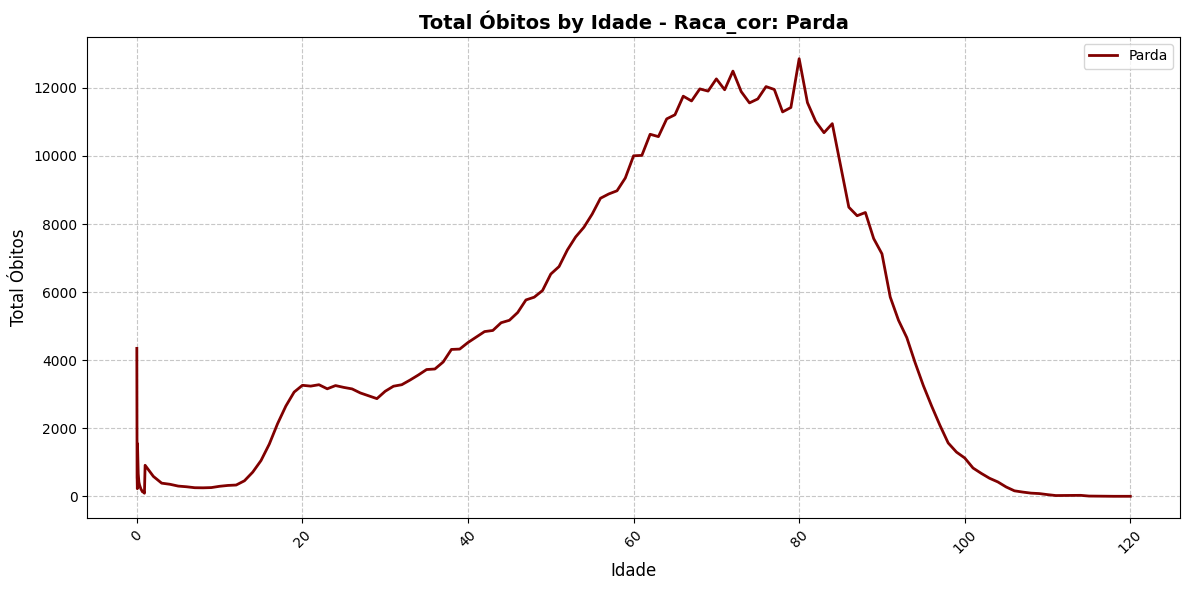

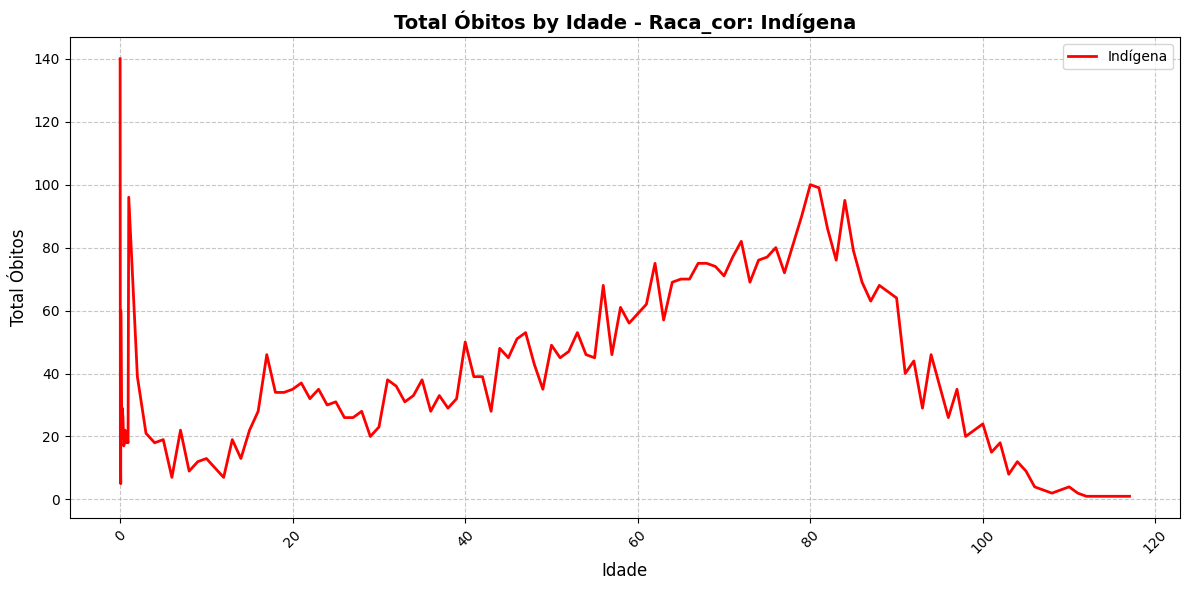

In [169]:
plot_subsector_categories(data, subsector='raca_cor', dictionary_colors=dictionary_colors, dictionary_labels=dictionary_labels, kind='line', figsize=(12, 6))

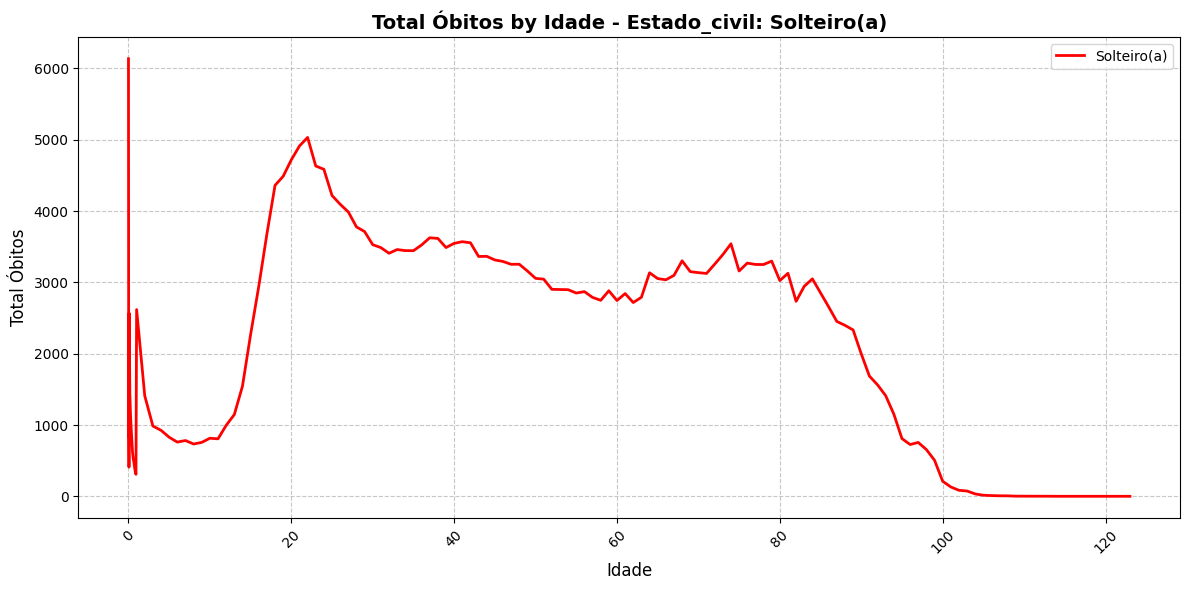

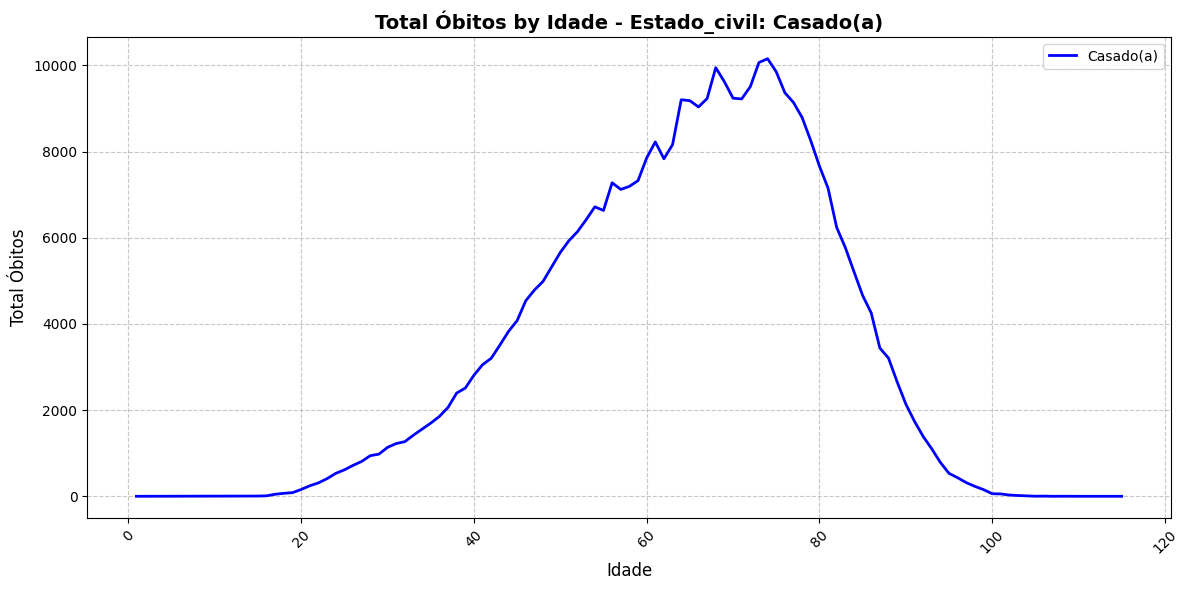

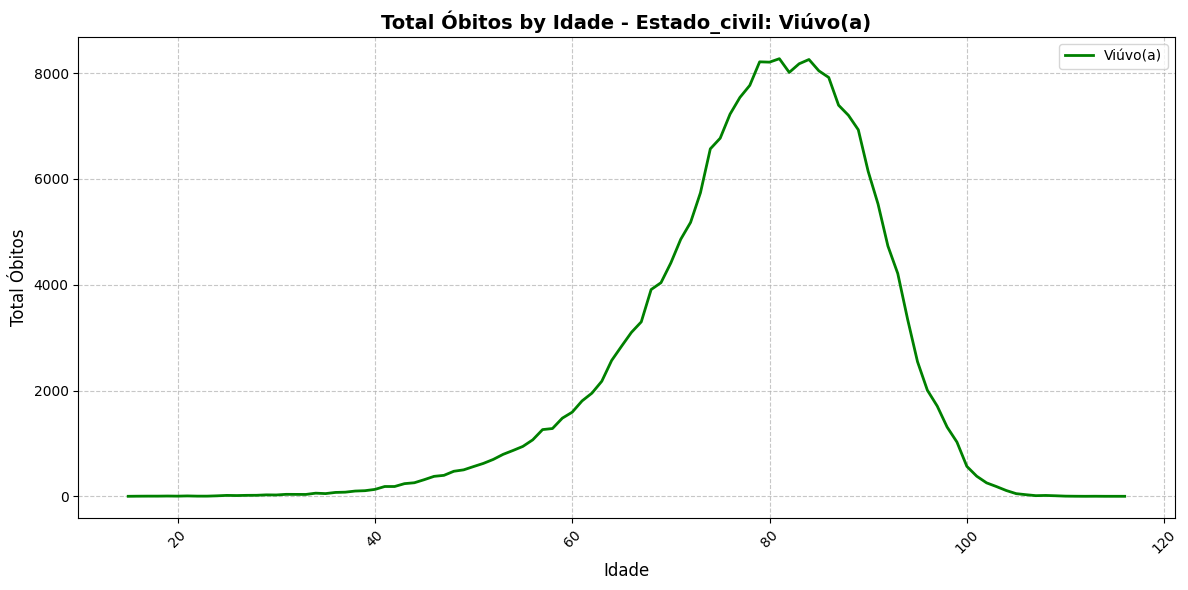

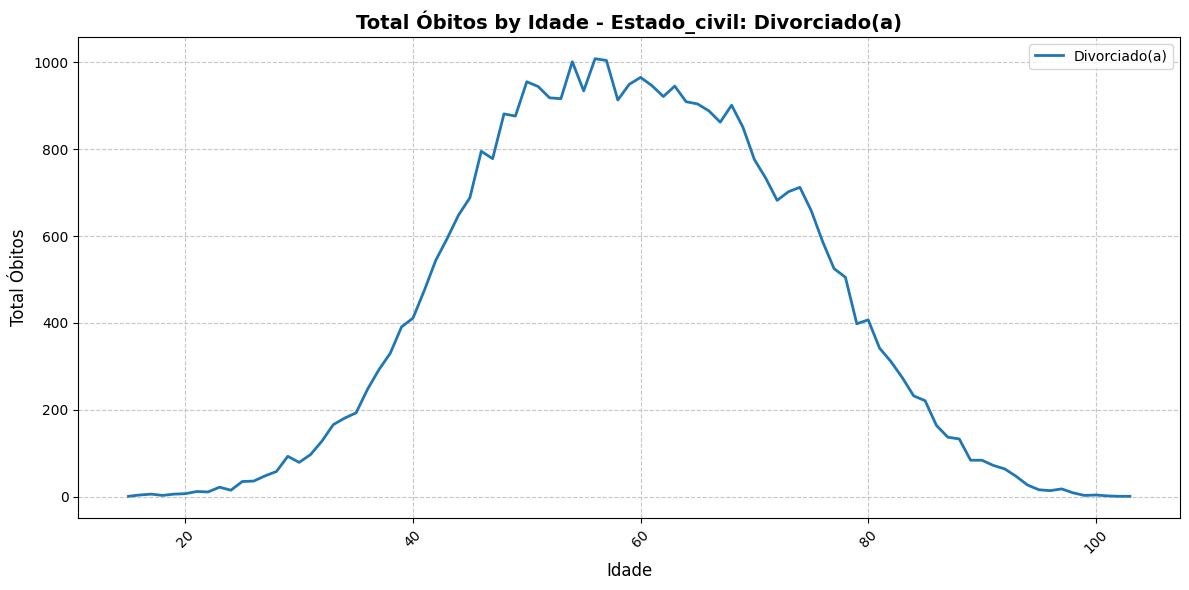

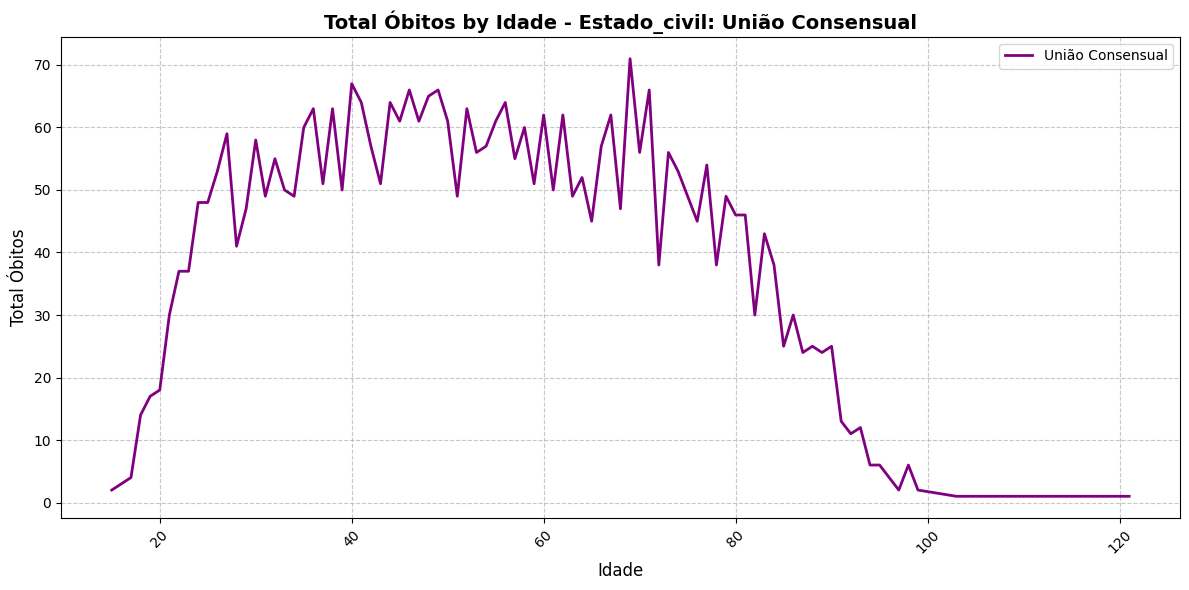

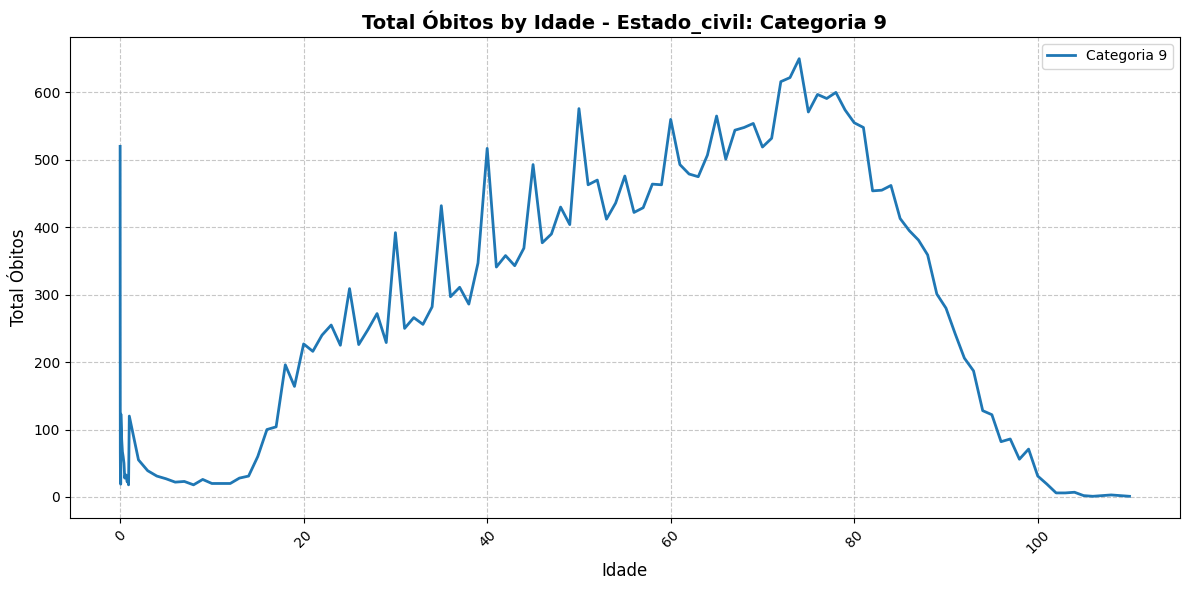

In [43]:
plot_subsector_categories(data, subsector='estado_civil', dictionary_colors=dictionary_colors, dictionary_labels=dictionary_labels, kind='line', figsize=(12, 6))

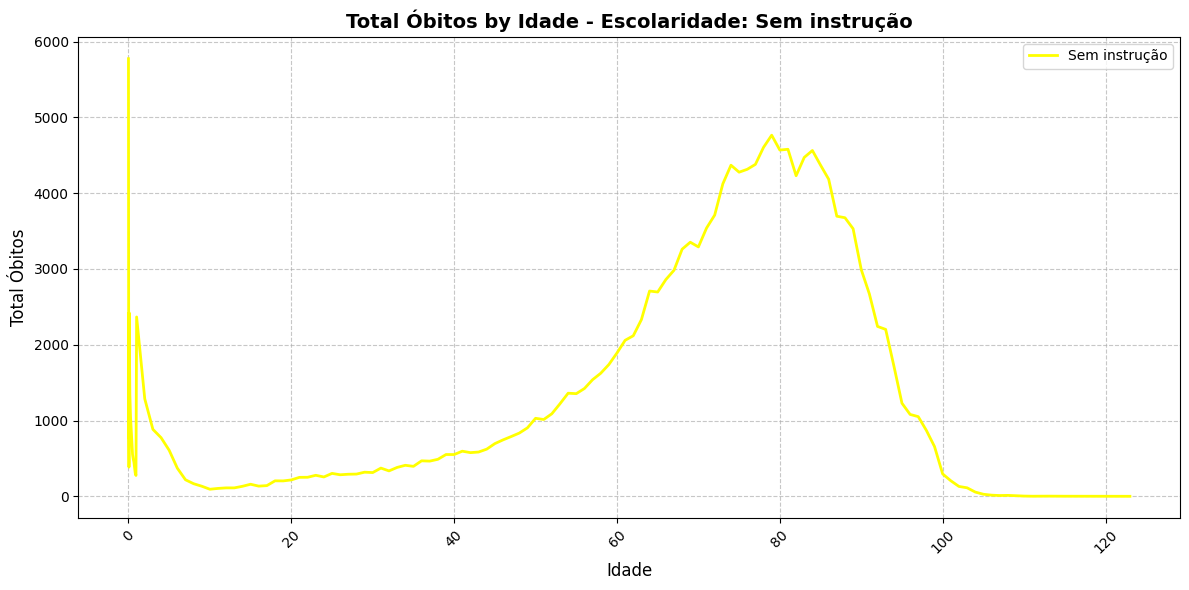

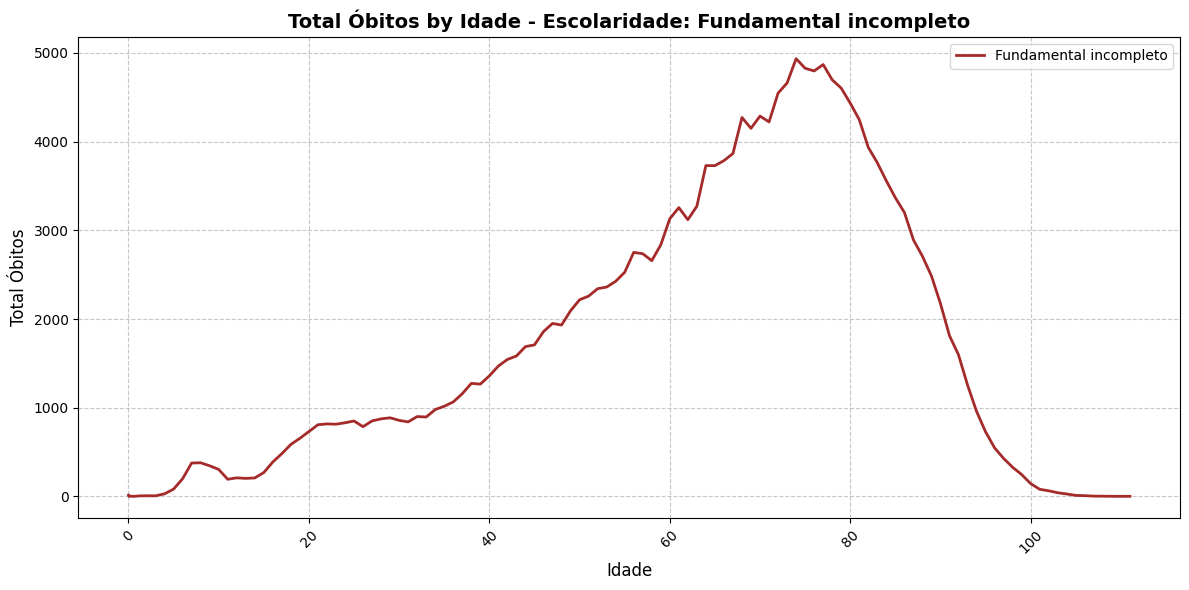

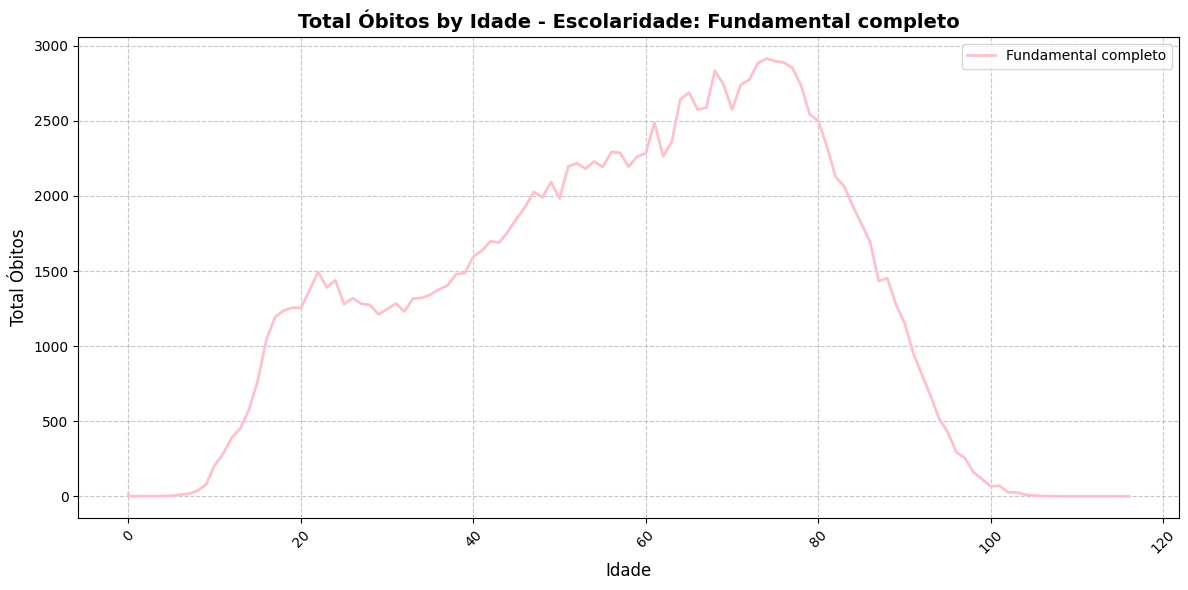

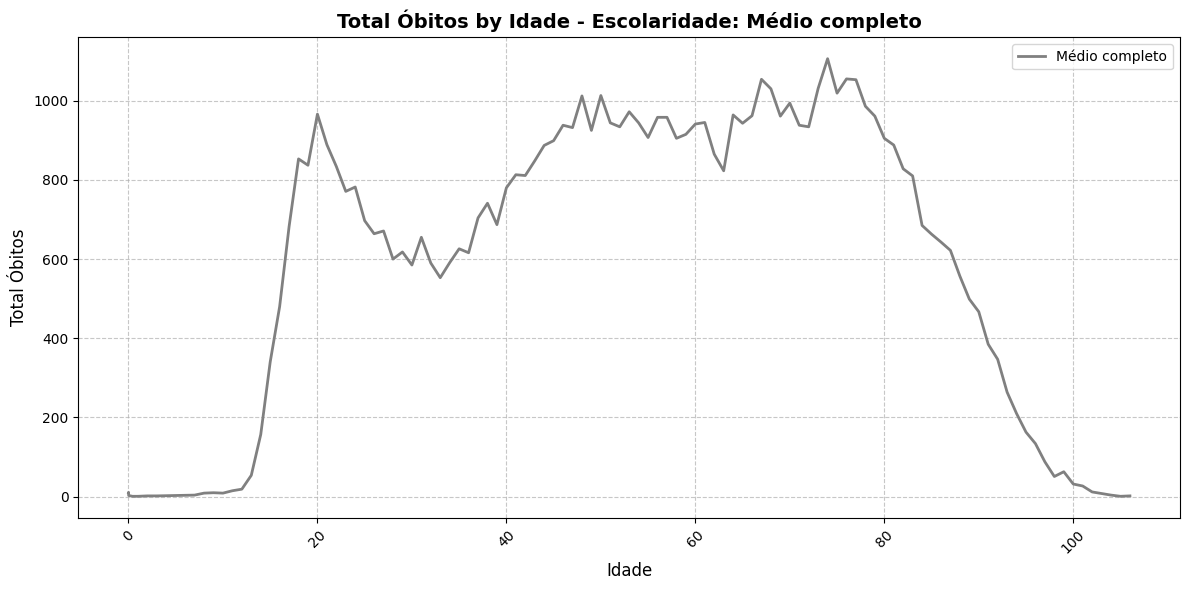

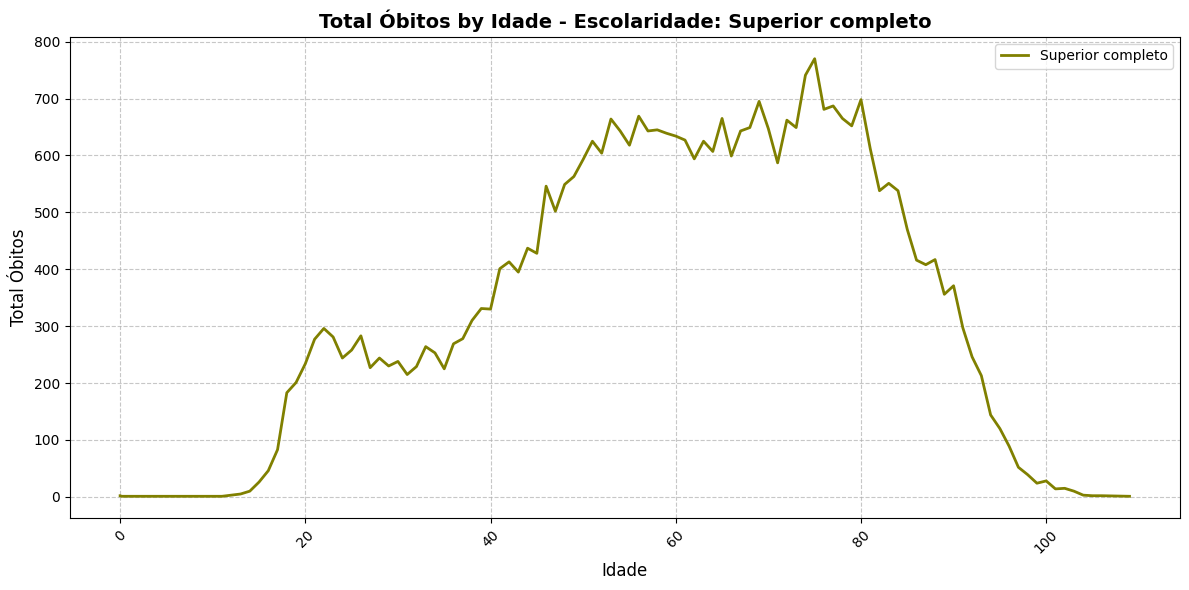

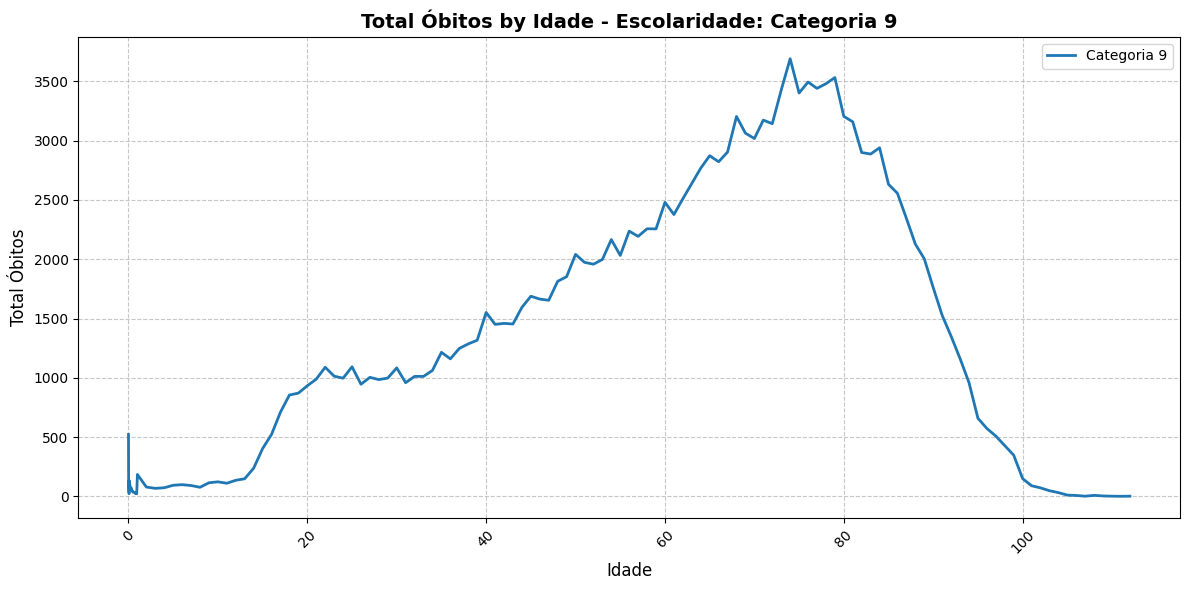

In [44]:
plot_subsector_categories(data, subsector='escolaridade', dictionary_colors=dictionary_colors, dictionary_labels=dicionary_labels, kind='line', figsize=(12, 6))

Plotting all subsectors...



C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


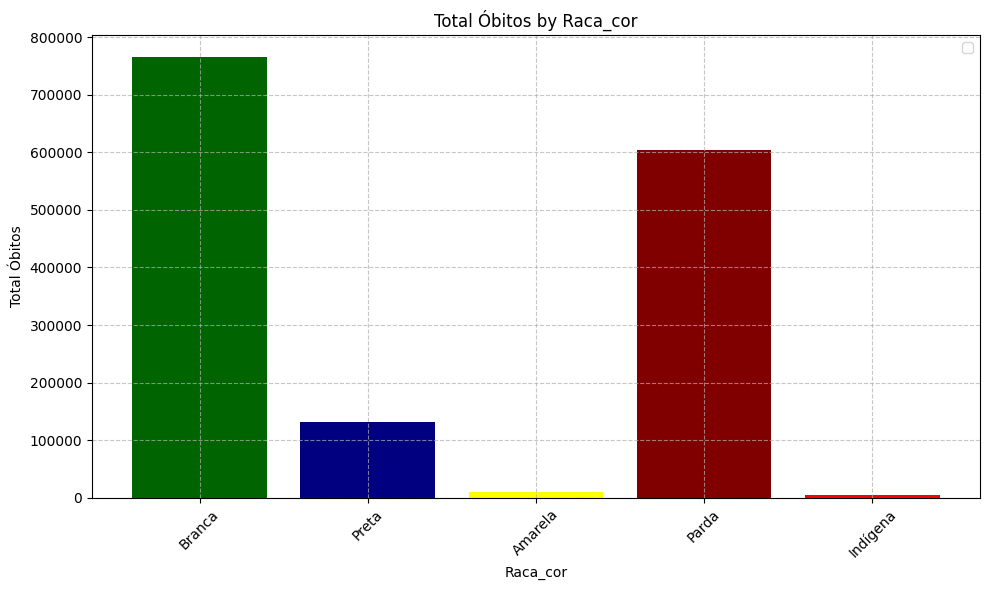

C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


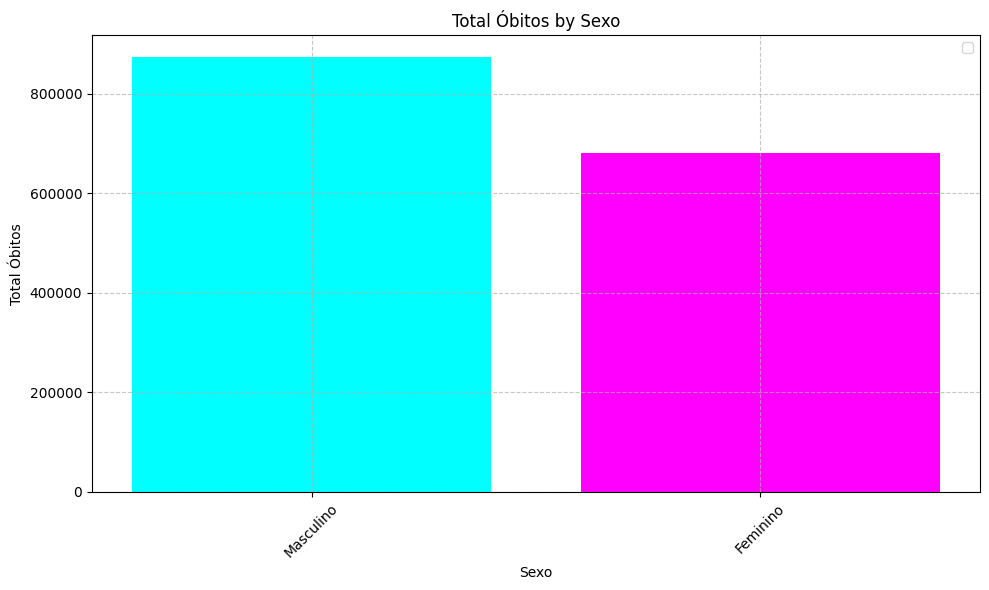

C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


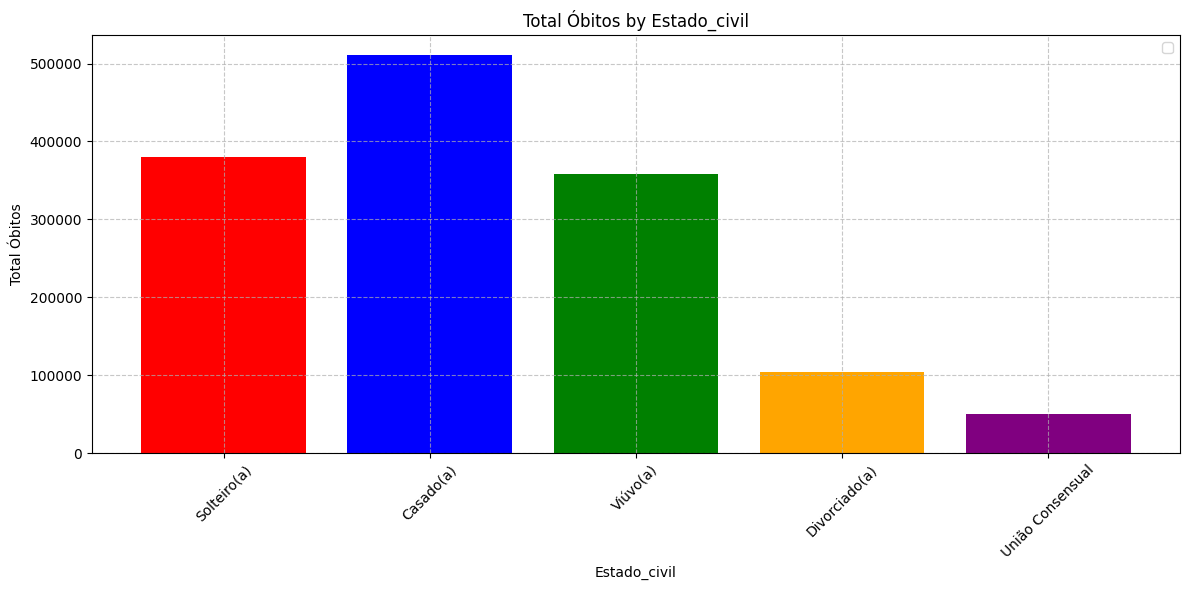

C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


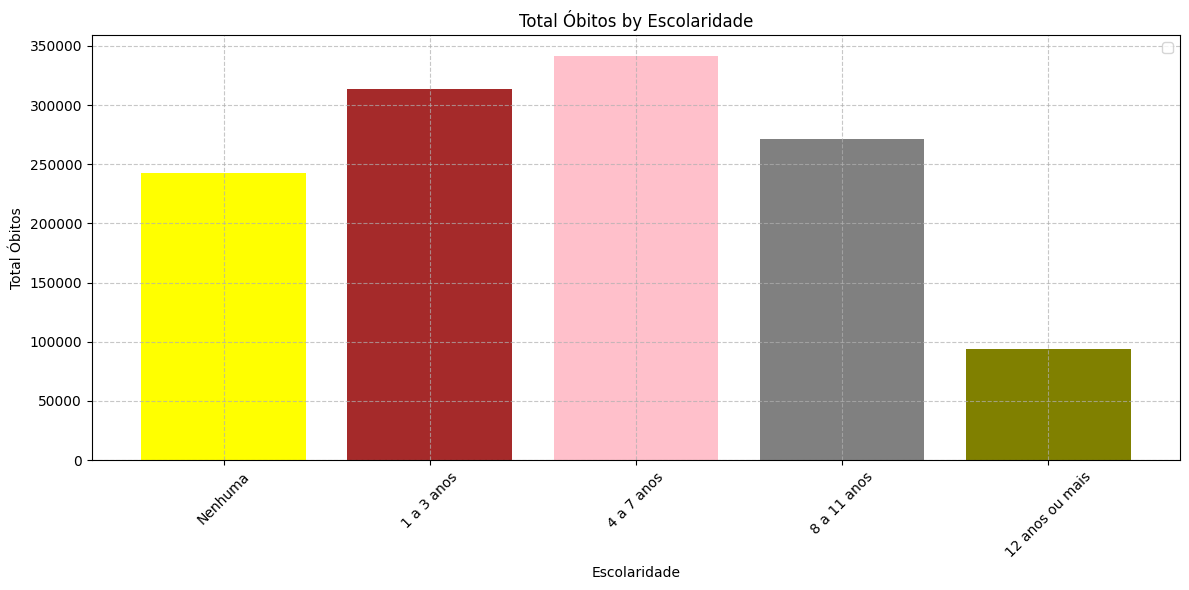

In [116]:
def plot_subsector_total(data, subsector, dictionary_colors, dictionary_labels, kind='bar', figsize=(10, 6)):
    """
    Plot total deaths by a subsector with proper labels and colors.
    
    Parameters:
    - data: Pandas DataFrame containing the data
    - subsector: String name of the subsector column (e.g., 'raca_cor', 'sexo')
    - dictionary_colors: Dict mapping subsector to dict of {subcategory_id: color}
    - dictionary_labels: Dict mapping subsector to dict of {subcategory_id: label}
    - kind: Type of plot ('bar', 'line', 'scatter')
    - figsize: Figure size tuple
    """
    # Group by subsector and count
    df_sub = data.groupby(subsector).size().reset_index(name='total_obitos')
    
    # Convert to int first, then to string to match dictionary keys
    df_sub['sub_str'] = df_sub[subsector].fillna(0).astype(int).astype(str)
    df_sub['colors'] = df_sub['sub_str'].map(dictionary_colors.get(subsector, {}))
    df_sub['label'] = df_sub['sub_str'].map(dictionary_labels.get(subsector, {}))
    
    # Remove rows with NaN labels (unmapped values)
    df_sub = df_sub.dropna(subset=['label'])
    
    # Plot
    plot_data(df_sub, x='label', y='total_obitos', kind=kind, 
              title=f'Total Óbitos by {subsector.capitalize()}', 
              xlabel=subsector.capitalize(), 
              ylabel='Total Óbitos', 
              color=df_sub['colors'].tolist(), 
              figsize=figsize)

# Example usage - plot all subsectors
print("Plotting all subsectors...\n")

plot_subsector_total(data, 'raca_cor', dictionary_colors, dictionary_labels, kind='bar', figsize=(10, 6))
plot_subsector_total(data, 'sexo', dictionary_colors, dictionary_labels, kind='bar', figsize=(10, 6))
plot_subsector_total(data, 'estado_civil', dictionary_colors, dictionary_labels, kind='bar', figsize=(12, 6))
plot_subsector_total(data, 'escolaridade', dictionary_colors, dictionary_labels, kind='bar', figsize=(12, 6))

In [30]:
# Calculate mX by age group -- mx = D/N where D is the number of deaths in the age group and N is the population in that age group.

# For this, we need to read the population data by age group from a reliable source (e.g., IBGE) and merge it with our death data by age group. Then we can calculate mX and plot it.



censo_2022 = "//Projetos2/Wrk/SIM-DATASUS/IBGE/censo2022.csv"
censo_2020 = "//Projetos2/Wrk/SIM-DATASUS/IBGE/censo2020.csv"





In [32]:
total_deaths

{'raca_cor': {'Branca': 764700,
  'Preta': 132076,
  'Amarela': 9479,
  'Parda': 604570,
  'Indígena': 5363},
 'sexo': {'Masculino': 874167, 'Feminino': 682027},
 'escolaridade': {'Nenhuma': 242935,
  '1 a 3 anos': 313154,
  '4 a 7 anos': 341822,
  '8 a 11 anos': 271668,
  '12 anos ou mais': 94045},
 'estado_civil': {'Solteiro(a)': 380712,
  'Casado(a)': 510767,
  'Viúvo(a)': 357874,
  'Divorciado(a)': 104506,
  'União Consensual': 49867}}

In [128]:

def subsector_categories(data, subsector, dictionary_labels):
    """
    Plot each subcategory of a subsector with its respective label and color.
    
    Parameters:
    - data: Pandas DataFrame containing the data
    - subsector: String name of the subsector column (e.g., 'sexo', 'raca_cor')
    - dictionary_colors: Dict mapping subsector to dict of {subcategory_id: color}
    - dictionary_labels: Dict mapping subsector to dict of {subcategory_id: label}
    - kind: Type of plot ('line', 'bar', 'scatter')
    - figsize: Figure size tuple
    """
    # Get unique subcategories for this subsector
    subcategories = sorted(data[subsector].dropna().unique())

    # Dataframe to hold total deaths by age for each subcategory
    df_total_by_age = pd.DataFrame()
    
    # Create a plot for each subcategory
    for subcategory in subcategories:
        subcategory_str = str(int(subcategory))
        
        # Filter data for this subcategory
        df_filtered = data[data[subsector] == subcategory].groupby('idade').size().reset_index(name='total_obitos')
        
        # Dataframe to hold will receive total deaths by age for this subcategory
        df_total_by_age[subcategory_str] = df_filtered.set_index('idade')['total_obitos']
    
    # Relabel columns using dictionary_labels
    df_total_by_age.rename(columns=dictionary_labels.get(subsector, {}), inplace=True)
    
    # Reset index to convert 'idade' from index to column and convert to int
    df_total_by_age = df_total_by_age.reset_index()
    df_total_by_age['idade'] = df_total_by_age['idade'].astype(int)

    return df_total_by_age

In [206]:
def deaths_by_age_group(data, age_col='idade', category_col=None, category_labels=None, 
                        format='auto', fill_na=True):
    """
    Calculate total deaths by age and optional subgroup/category.
    
    Parameters:
    - data: Input DataFrame with death records
    - age_col: Column name for age (default: 'idade')
    - category_col: Column name for category/subgroup (e.g., 'raca_cor', 'sexo', 'escolaridade')
                    If None, returns only deaths by age
    - category_labels: Dict to map category codes to labels (e.g., {'1': 'Masculino', '2': 'Feminino'})
    - format: 'auto' (pivot if category_col), 'long' (long format), or 'pivot' (wide format)
    - fill_na: If True, fill NaN values with 0 in pivot format
    
    Returns:
    - If category_col is None: DataFrame with ['idade', 'deaths']
    - If format='pivot': DataFrame with 'idade' as index and categories as columns
    - If format='long': DataFrame with ['idade', 'category', 'deaths']
    """
    
    df = data.copy()
    
    # Standardize age column
    df[age_col] = pd.to_numeric(df[age_col], errors='coerce').fillna(0).astype(int)
    
    # Case 1: Only age grouping (no category)
    if category_col is None:
        deaths_age = df.groupby(age_col).size().reset_index(name='deaths')
        deaths_age.columns = ['idade', 'deaths']
        return deaths_age.sort_values('idade').reset_index(drop=True)
    
    # Case 2: Age and category grouping
    # Standardize category column
    # Convert float to int first (handles 1.0 -> 1), then to string
    df[category_col] = df[category_col].fillna(0)  # Fill NaN with 0
    if df[category_col].dtype == 'float64':
        df[category_col] = df[category_col].astype(int).astype(str)
    else:
        df[category_col] = df[category_col].astype(str).str.strip()
    
    # Group by age and category
    deaths_grouped = df.groupby([age_col, category_col]).size().reset_index(name='deaths')
    deaths_grouped.columns = ['idade', 'category_code', 'deaths']
    
    # Apply category labels if provided
    if category_labels:
        # Normalize keys in dictionary (convert to string)
        normalized_labels = {str(k): v for k, v in category_labels.items()}
        deaths_grouped['category_name'] = deaths_grouped['category_code'].map(normalized_labels)
        # Keep only rows with mapped labels (excluding unmapped like '0' for NaN)
        deaths_grouped = deaths_grouped.dropna(subset=['category_name'])
    else:
        deaths_grouped['category_name'] = deaths_grouped['category_code']
    
    # Return in requested format
    if format == 'pivot' or (format == 'auto' and category_col):
        # Pivot to wide format
        pivot_df = deaths_grouped.pivot_table(
            index='idade',
            columns='category_name',
            values='deaths',
            aggfunc='sum'
        )
        if fill_na:
            pivot_df = pivot_df.fillna(0).astype(int)
        return pivot_df.reset_index()
    
    else:  # format == 'long'
        return deaths_grouped[['idade', 'category_name', 'deaths']].sort_values(['idade', 'category_name']).reset_index(drop=True)


In [195]:
# Examples: Calculate deaths by age and subgroup

print("="*70)
print("EXAMPLE 1: Deaths by age only")
print("="*70)
deaths_by_age = deaths_by_age_group(data, age_col='idade')
print(deaths_by_age.head(10))
print(f"Total ages: {len(deaths_by_age)}")
print(f"Total deaths: {deaths_by_age['deaths'].sum()}")

print("\n" + "="*70)
print("EXAMPLE 2: Deaths by age and race/color (PIVOT format)")
print("="*70)
deaths_by_age_race_pivot = deaths_by_age_group(
    data, 
    age_col='idade', 
    category_col='raca_cor',
    category_labels=dictionary_labels['raca_cor'],
    format='pivot'
)
print(deaths_by_age_race_pivot.head(10))
print(f"\nShape: {deaths_by_age_race_pivot.shape}")
print(f"Columns: {deaths_by_age_race_pivot.columns.tolist()}")

print("\n" + "="*70)
print("EXAMPLE 3: Deaths by age and sex (LONG format)")
print("="*70)
deaths_by_age_sex_long = deaths_by_age_group(
    data, 
    age_col='idade', 
    category_col='sexo',
    category_labels=dictionary_labels['sexo'],
    format='long'
)
print(deaths_by_age_sex_long.head(15))
print(f"\nShape: {deaths_by_age_sex_long.shape}")

print("\n" + "="*70)
print("EXAMPLE 4: Deaths by age and education (PIVOT format)")
print("="*70)
deaths_by_age_education = deaths_by_age_group(
    data, 
    age_col='idade', 
    category_col='escolaridade',
    category_labels=dictionary_labels['escolaridade'],
    format='pivot',
    fill_na=True
)
print(deaths_by_age_education.head(10))
print(f"Shape: {deaths_by_age_education.shape}")

print("\n" + "="*70)
print("FUNCTION SUMMARY")
print("="*70)
print("""
deaths_by_age_group() - Flexible deaths aggregation by age and subgroup

Parameters:
  - data: Raw DataFrame with individual death records
  - age_col: Column name for age (default: 'idade')
  - category_col: Optional category column (raca_cor, sexo, escolaridade, etc.)
  - category_labels: Dict to map codes to human-readable labels
  - format: 'auto', 'pivot' (wide), or 'long' (tall)
  - fill_na: Fill missing values with 0 in pivot format

Returns:
  - Deaths aggregated by age (and category if provided)
  - Automatically converts age to integer
  - Applies category labels for better readability
  - Can return in pivot (wide) or long (tall) format

Example usage:
  # By age only
  df = deaths_by_age_group(data)
  
  # By age and category (pivot)
  df = deaths_by_age_group(data, category_col='sexo', 
                          category_labels=labels_dict, format='pivot')
  
  # By age and category (long)
  df = deaths_by_age_group(data, category_col='raca_cor', 
                          category_labels=labels_dict, format='long')
""")

EXAMPLE 1: Deaths by age only
   idade  deaths
0      0   33826
1      1    1951
2      2    1173
3      3     789
4      4     673
5      5     624
6      6     523
7      7     495
8      8     451
9      9     489
Total ages: 122
Total deaths: 1556824

EXAMPLE 2: Deaths by age and race/color (PIVOT format)
Empty DataFrame
Columns: [idade]
Index: []

Shape: (0, 1)
Columns: ['idade']

EXAMPLE 3: Deaths by age and sex (LONG format)
    idade category_name  deaths
0       0      Feminino   14173
1       0     Masculino   19121
2       1      Feminino     932
3       1     Masculino    1019
4       2      Feminino     537
5       2     Masculino     635
6       3      Feminino     345
7       3     Masculino     444
8       4      Feminino     284
9       4     Masculino     389
10      5      Feminino     279
11      5     Masculino     345
12      6      Feminino     215
13      6     Masculino     308
14      7      Feminino     201

Shape: (241, 3)

EXAMPLE 4: Deaths by age and educa

In [182]:
# Display by subsectors ['raca_cor', 'sexo', 'escolaridade', 'estado_civil']
subsectors = ['raca_cor', 'sexo']

# Receive total deaths by age for each subsector category in a dictionary of DataFrames
dfs = {}

for subsector in subsectors:
    df_total_by_age = subsector_categories(data, subsector, dictionary_labels)
    
    dfs[subsector] = df_total_by_age

# Total deaths by age
df_filtered = data.groupby('idade').size().reset_index(name='total_obitos')
df_filtered['idade'] = df_filtered['idade'].astype(int)
dfs['total_by_age'] = df_filtered

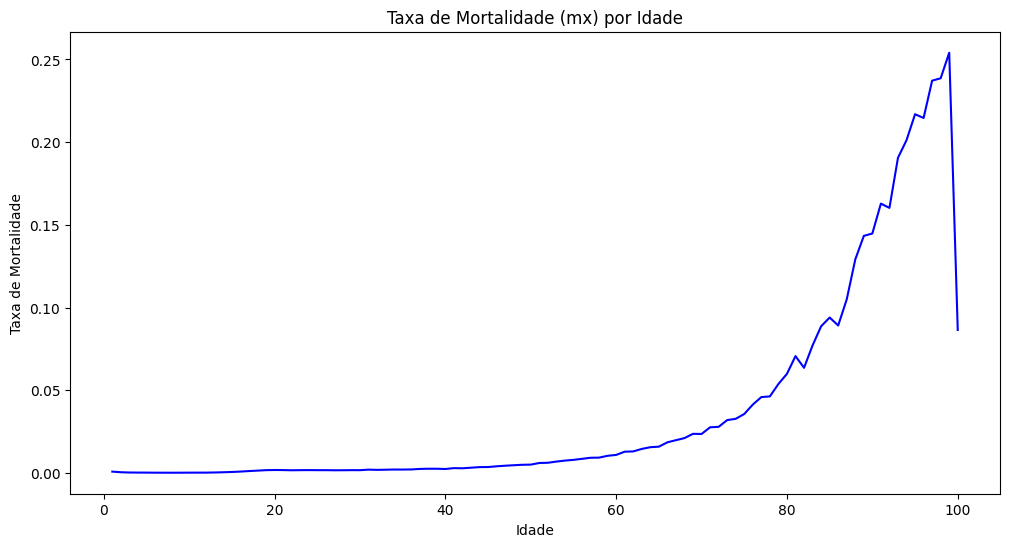

In [81]:
# Calculate mx by age group for the entire dataset
deaths_by_age = dfs['total_by_age'].reset_index()

censo_2022 = "//Projetos2/Wrk/SIM-DATASUS/IBGE/censo2022.csv"

censo_2022_df = pd.read_csv(censo_2022)

# Get only total column 
censo_2022_df[['Idade','Total']]

deaths_by_age.rename(columns={'idade': 'Idade Morte', 'total_obitos': 'Total Obitos'}, inplace=True)
censo_2022_df.rename(columns={'Idade': 'Idade Censo', 'Total': 'Total Populacao'}, inplace=True)

# Turning into int for merging
deaths_by_age['Idade Morte'] = deaths_by_age['Idade Morte'].astype(int)
censo_2022_df['Idade Censo'] = censo_2022_df['Idade Censo'].astype(int)

# Merge deaths by age with population by age
merged_df = pd.merge(deaths_by_age, censo_2022_df, left_on='Idade Morte', right_on='Idade Censo', how='inner')

# Calculate mx = D/N
merged_df['mx'] = merged_df['Total Obitos'] / merged_df['Total Populacao']

# Plot mx by age group
plt.figure(figsize=(12, 6))
plt.plot(merged_df['Idade Morte'], merged_df['mx'], color='blue')
plt.title('Taxa de Mortalidade (mx) por Idade')
plt.xlabel('Idade')
plt.ylabel('Taxa de Mortalidade')
plt.show()


In [179]:
def standardize_data(df, age_col=None, count_col=None, category_col=None):
    """
    Standardize any demographic data to a common format.
    
    Parameters:
    - df: Input DataFrame
    - age_col: Name of the age/idade column (if None, auto-detect)
    - count_col: Name of the count/total column (if None, auto-detect)
    - category_col: Optional category column name (e.g., 'raca_cor', 'sexo')
    
    Returns:
    - Standardized DataFrame with columns: ['idade', 'count'] or ['idade', 'count', category_col]
    """
    df_std = df.copy()
    
    # AUTO-DETECT AGE COLUMN
    if age_col is None:
        age_candidates = [col for col in df_std.columns if col.lower() in ['idade', 'age', 'age_group', 'faixa etária']]
        if not age_candidates:
            raise ValueError(f"Could not find age column. Available columns: {df_std.columns.tolist()}")
        age_col = age_candidates[0]
    
    # AUTO-DETECT COUNT COLUMN (if not the age column)
    if count_col is None:
        exclude_cols = {age_col, category_col} if category_col else {age_col}
        # Prioritize numeric columns
        numeric_cols = df_std.select_dtypes(include=['int64', 'float64']).columns.tolist()
        count_candidates = [col for col in numeric_cols if col not in exclude_cols]
        
        if not count_candidates:
            raise ValueError(f"Could not find count column. Available numeric columns: {numeric_cols}")
        
        # If there are multiple numeric columns, take the first non-id column
        count_col = count_candidates[0]
    
    # Standardize column names
    rename_map = {age_col: 'idade', count_col: 'count'}
    if category_col and category_col in df_std.columns:
        rename_map[category_col] = 'category'
    
    df_std.rename(columns=rename_map, inplace=True)
    
    # Convert idade to integer (handle decimals by truncating)
    df_std['idade'] = df_std['idade'].astype(float).astype(int)
    
    # Ensure count is numeric
    df_std['count'] = pd.to_numeric(df_std['count'], errors='coerce')
    
    # Select only necessary columns
    cols_to_keep = ['idade', 'count']
    if 'category' in df_std.columns:
        cols_to_keep.append('category')
    
    df_std = df_std[cols_to_keep].reset_index(drop=True)
    
    # Drop rows with NaN values
    df_std = df_std.dropna()
    
    return df_std


def calculate_mx(deaths_data, population_data, deaths_age_col=None, deaths_count_col=None,
                 pop_age_col=None, pop_count_col=None):
    """
    Calculate mortality rate (mx) by age group.
    
    mx = D/N where:
    - D = number of deaths in age group
    - N = population in that age group
    
    Parameters:
    - deaths_data: DataFrame with deaths by age
    - population_data: DataFrame with population by age
    - deaths_age_col: Age column name in deaths_data (auto-detect if None)
    - deaths_count_col: Count column name in deaths_data (auto-detect if None)
    - pop_age_col: Age column name in population_data (auto-detect if None)
    - pop_count_col: Count column name in population_data (auto-detect if None)
    
    Returns:
    - DataFrame with columns: ['idade', 'deaths', 'population', 'mx']
    """
    
    # Standardize both datasets
    deaths_std = standardize_data(deaths_data, age_col=deaths_age_col, count_col=deaths_count_col)
    population_std = standardize_data(population_data, age_col=pop_age_col, count_col=pop_count_col)
    
    # Rename count columns to be descriptive
    deaths_std.rename(columns={'count': 'deaths'}, inplace=True)
    population_std.rename(columns={'count': 'population'}, inplace=True)
    
    # Merge on idade
    merged = pd.merge(deaths_std, population_std, on='idade', how='inner')
    
    # Calculate mortality rate
    merged['mx'] = merged['deaths'] / merged['population']
    
    return merged[['idade', 'deaths', 'population', 'mx']]

EXAMPLE 1: Calculate mx for total population (all deaths vs population)

Mortality Rate (mx) by Age:
    idade  deaths  population        mx
0       1    1951     2353945  0.000829
1       2    1173     2563419  0.000458
2       3     789     2699784  0.000292
3       4     673     2729447  0.000247
4       5     624     2640786  0.000236
5       6     523     2771512  0.000189
6       7     495     2831711  0.000175
7       8     451     2740900  0.000165
8       9     489     2764531  0.000177
9      10     565     2701639  0.000209
10     11     588     2717865  0.000216
11     12     636     2773621  0.000229
12     13     857     2745700  0.000312
13     14    1234     2736136  0.000451
14     15    1732     2819510  0.000614

Shape: (100, 4)
Age range: 1 to 100


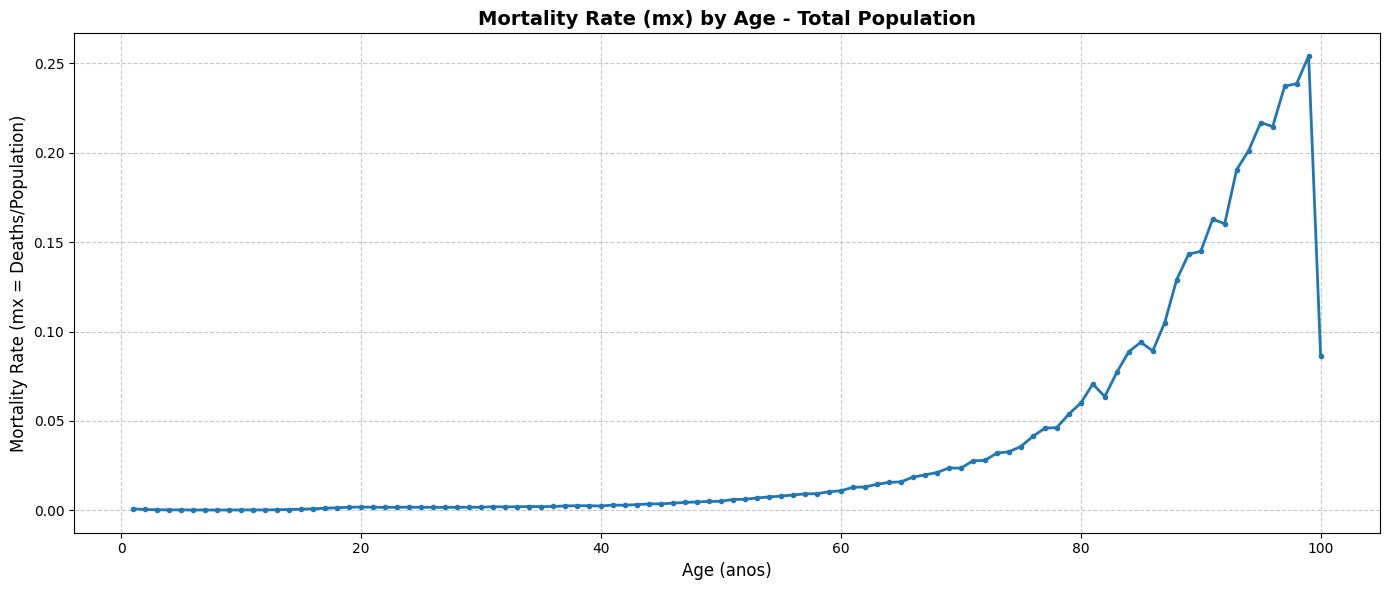


EXAMPLE 2: Calculate mx by race/color (raca_cor)

Deaths by race shape: (137, 6)
Columns: ['idade', 'Branca', 'Preta', 'Amarela', 'Parda', 'Indígena']

Branca:
  Shape: (100, 4)
  Age range: 1 to 100
  Mean mx: 0.038937
  First 5 ages:
   idade  deaths  population        mx
0      1     750     1093024  0.000686
1      2     462     1156433  0.000400
2      3     319     1192333  0.000268
3      4     241     1190253  0.000202
4      5     255     1134636  0.000225

Preta:
  Shape: (100, 4)
  Age range: 1 to 100
  Mean mx: 0.027425
  First 5 ages:
   idade  deaths  population        mx
0      1    89.0      143231  0.000621
1      2    40.0      164812  0.000243
2      3    30.0      179732  0.000167
3      4    28.0      187895  0.000149
4      5    26.0      187811  0.000138

Parda:
  Shape: (100, 4)
  Age range: 1 to 100
  Mean mx: 0.034679
  First 5 ages:
   idade  deaths  population        mx
0      1   912.0     1084986  0.000841
1      2   585.0     1208528  0.000484
2      3  

In [ ]:
# Example: Calculate mx for entire dataset
print("=" * 70)
print("EXAMPLE 1: Calculate mx for total population (all deaths vs population)")
print("=" * 70)


# Load population data
censo_2022 = "//Projetos2/Wrk/SIM-DATASUS/IBGE/censo2022.csv"
censo_2022_df = pd.read_csv(censo_2022)

# Use the standardized function
mx_total = calculate_mx(
    deaths_data=dfs['total_by_age'],
    population_data=censo_2022_df,
    deaths_age_col='idade',
    deaths_count_col='total_obitos',
    pop_age_col='Idade',
    pop_count_col='Total'
)

print("\nMortality Rate (mx) by Age:")
print(mx_total.head(15))
print(f"\nShape: {mx_total.shape}")
print(f"Age range: {mx_total['idade'].min()} to {mx_total['idade'].max()}")

# Visualize
plt.figure(figsize=(14, 6))
plt.plot(mx_total['idade'], mx_total['mx'], linewidth=2, marker='o', markersize=3)
plt.title('Mortality Rate (mx) by Age - Total Population', fontsize=14, fontweight='bold')
plt.xlabel('Age (anos)', fontsize=12)
plt.ylabel('Mortality Rate (mx = Deaths/Population)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("EXAMPLE 2: Calculate mx by race/color (raca_cor)")
print("=" * 70)

# Get deaths by race
deaths_by_race = dfs['raca_cor']
print(f"\nDeaths by race shape: {deaths_by_race.shape}")
print(f"Columns: {deaths_by_race.columns.tolist()}")

# For each race, calculate mx
for race_col in ['Branca', 'Preta', 'Parda', 'Indígena']:  # Use available race columns
    print(f"\n{race_col}:")
    
    try:
        # Prepare deaths data (just idade and this race)
        deaths_subset = deaths_by_race[['idade', race_col]].copy()
        deaths_subset.columns = ['idade', 'count']
        
        # Prepare population data (just Idade and this race) - note uppercase Idade
        pop_subset = censo_2022_df[['Idade', race_col]].copy()
        pop_subset.columns = ['Idade', 'count']
        
        # Calculate mx
        mx_race = calculate_mx(
            deaths_data=deaths_subset,
            population_data=pop_subset,
            deaths_age_col='idade',
            deaths_count_col='count',
            pop_age_col='Idade',
            pop_count_col='count'
        )
        
        print(f"  Shape: {mx_race.shape}")
        print(f"  Age range: {mx_race['idade'].min()} to {mx_race['idade'].max()}")
        print(f"  Mean mx: {mx_race['mx'].mean():.6f}")
        print(f"  First 5 ages:")
        print(mx_race[['idade', 'deaths', 'population', 'mx']].head())
    except Exception as e:
        print(f"  Error: {str(e)}")

print("\n" + "=" * 70)
print("SUMMARY: standardize_data() and calculate_mx() functions")
print("=" * 70)
print("""
✓ These functions handle data with different column names and formats
✓ Automatically detects age and count columns (can be customized)
✓ Converts age values to integers (handles decimals)
✓ Merges death and population data by age
✓ Calculates mortality rate (mx = deaths/population)

Usage:
    mx_result = calculate_mx(
        deaths_data=df_deaths,
        population_data=df_population,
        deaths_age_col='age_column_name',        # Optional: auto-detect if None
        deaths_count_col='count_column_name',    # Optional: auto-detect if None
        pop_age_col='population_age_col',        # Optional: auto-detect if None
        pop_count_col='population_count_col'     # Optional: auto-detect if None
    )
""")


In [183]:
# DEBUG: Check data structure
print("Deaths data columns:", dfs['total_by_age'].columns.tolist())
print("Deaths data dtypes:")
print(dfs['total_by_age'].dtypes)
print("\nDeaths data head:")
print(dfs['total_by_age'].head(3))
print("\n" + "="*70)

censo_2022 = "//Projetos2/Wrk/SIM-DATASUS/IBGE/censo2022.csv"
censo_2022_df = pd.read_csv(censo_2022)
print("\nPopulation data columns:", censo_2022_df.columns.tolist())
print("Population data dtypes:")
print(censo_2022_df.dtypes)
print("\nPopulation data head:")
print(censo_2022_df.head(3))

Deaths data columns: ['idade', 'total_obitos']
Deaths data dtypes:
idade           int64
total_obitos    int64
dtype: object

Deaths data head:
   idade  total_obitos
0      0          8154
1      0          5570
2      0          2268


Population data columns: ['Unnamed: 0', 'Idade', 'Total', 'Branca', 'Preta', 'Amarela', 'Parda', 'Indígena']
Population data dtypes:
Unnamed: 0    object
Idade          int64
Total          int64
Branca         int64
Preta          int64
Amarela        int64
Parda          int64
Indígena       int64
dtype: object

Population data head:
  Unnamed: 0  Idade    Total   Branca   Preta  Amarela    Parda  Indígena
0     Brasil      1  2353945  1093024  143231     4829  1084986     27751
1     Brasil      2  2563419  1156433  164812     5512  1208528     28027
2     Brasil      3  2699784  1192333  179732     6002  1293140     28471


In [170]:
eleitorado = "//Projetos2/Wrk/SIM-DATASUS/eleitorado.csv"
eleitorado_df = pd.read_csv(eleitorado)


C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\140717119.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  eleitorado_df = pd.read_csv(eleitorado)


In [187]:
eleitorado_df.head(100)

,ano_referencia,regiao,SG_UF,NM_MUNICIPIO,DS_FAIXA_ETARIA,DS_GENERO,DS_COR_RACA,DS_GRAU_INSTRUCAO,DS_ESTADO_CIVIL,qt_eleitores
0,2004,Centro-Oeste,DF,BRASILIA,#NE,FEMININO,NaN,ANALFABETO,#NE,22897
1,2004,Centro-Oeste,DF,BRASILIA,#NE,FEMININO,NaN,ENSINO FUNDAMENTAL COMPLETO,#NE,71811
2,2004,Centro-Oeste,DF,BRASILIA,#NE,FEMININO,NaN,ENSINO FUNDAMENTAL INCOMPLETO,#NE,227241
3,2004,Centro-Oeste,DF,BRASILIA,#NE,FEMININO,NaN,ENSINO MÉDIO COMPLETO,#NE,151236
4,2004,Centro-Oeste,DF,BRASILIA,#NE,FEMININO,NaN,ENSINO MÉDIO INCOMPLETO,#NE,158570
...,...,...,...,...,...,...,...,...,...,...
95,2004,Centro-Oeste,GO,AGUA FRIA DE GOIAS,#NE,FEMININO,NaN,ANALFABETO,#NE,157
96,2004,Centro-Oeste,GO,AGUA FRIA DE GOIAS,#NE,FEMININO,NaN,ENSINO FUNDAMENTAL COMPLETO,#NE,147
97,2004,Centro-Oeste,GO,AGUA FRIA DE GOIAS,#NE,FEMININO,NaN,ENSINO FUNDAMENTAL INCOMPLETO,#NE,738
98,2004,Centro-Oeste,GO,AGUA FRIA DE GOIAS,#NE,FEMININO,NaN,ENSINO MÉDIO COMPLETO,#NE,196


In [207]:
df_sexo = deaths_by_age_group(data, age_col='idade', category_col='sexo', category_labels=dictionary_labels['sexo'], format='pivot', fill_na=True)

df_raca_cor = deaths_by_age_group(data, age_col='idade', category_col='raca_cor', category_labels=dictionary_labels['raca_cor'], format='pivot', fill_na=True)


In [208]:
print("="*70)
print("CHECK: df_raca_cor (Deaths by age and race/color)")
print("="*70)
print(f"\nShape: {df_raca_cor.shape}")
print(f"Columns: {df_raca_cor.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(df_raca_cor.head(10))

print(f"\nData types:")
print(df_raca_cor.dtypes)

print(f"\nBasic statistics:")
print(df_raca_cor.describe())

print("\n" + "="*70)
print("COMPARISON: df_sexo vs df_raca_cor")
print("="*70)
print(f"\ndf_sexo shape: {df_sexo.shape}")
print(f"df_sexo columns: {df_sexo.columns.tolist()}")

print(f"\ndf_raca_cor shape: {df_raca_cor.shape}")
print(f"df_raca_cor columns: {df_raca_cor.columns.tolist()}")

# Verify no NaN values
print("\n" + "="*70)
print("NaN CHECK")
print("="*70)
print(f"\ndf_sexo NaN count:\n{df_sexo.isna().sum()}")
print(f"\ndf_raca_cor NaN count:\n{df_raca_cor.isna().sum()}")

# Total deaths comparison
print("\n" + "="*70)
print("TOTAL DEATHS COMPARISON")
print("="*70)
print(f"\ndf_sexo total deaths: {df_sexo.iloc[:, 1:].sum().sum()}")
print(f"df_raca_cor total deaths: {df_raca_cor.iloc[:, 1:].sum().sum()}")
print(f"Combined should match original data: {data.shape[0]}")


CHECK: df_raca_cor (Deaths by age and race/color)

Shape: (122, 6)
Columns: ['idade', 'Amarela', 'Branca', 'Indígena', 'Parda', 'Preta']

First 10 rows:
category_name  idade  Amarela  Branca  Indígena  Parda  Preta
0                  0       87   11899       599  16988   1076
1                  1        8     750        96    912     89
2                  2        1     462        39    585     40
3                  3        4     319        21    387     30
4                  4        6     241        18    354     28
5                  5        0     255        19    301     26
6                  6        2     189         7    281     29
7                  7        0     167        22    253     33
8                  8        1     151         9    250     26
9                  9        0     177        12    257     29

Data types:
category_name
idade       int64
Amarela     int64
Branca      int64
Indígena    int64
Parda       int64
Preta       int64
dtype: object

Basic statistic

In [209]:
print("\n" + "="*70)
print("FINAL CHECK: raca_cor is now FIXED! ✓")
print("="*70)
print(f"\n✓ df_raca_cor shape: {df_raca_cor.shape}")
print(f"✓ df_raca_cor columns: {df_raca_cor.columns.tolist()}")
print(f"✓ Total deaths: {df_raca_cor.iloc[:, 1:].sum().sum():.0f}")
print(f"✓ Age range: {df_raca_cor['idade'].min()} - {df_raca_cor['idade'].max()}")

print(f"\n✓ df_sexo shape: {df_sexo.shape}")
print(f"✓ df_sexo columns: {df_sexo.columns.tolist()}")
print(f"✓ Total deaths: {df_sexo.iloc[:, 1:].sum().sum():.0f}")

print(f"\n✓ MATCH: Both DataFrames have same total deaths: {abs(df_raca_cor.iloc[:, 1:].sum().sum() - df_sexo.iloc[:, 1:].sum().sum()) < 1}")



FINAL CHECK: raca_cor is now FIXED! ✓

✓ df_raca_cor shape: (122, 6)
✓ df_raca_cor columns: ['idade', 'Amarela', 'Branca', 'Indígena', 'Parda', 'Preta']
✓ Total deaths: 1516188
✓ Age range: 0 - 125

✓ df_sexo shape: (122, 3)
✓ df_sexo columns: ['idade', 'Feminino', 'Masculino']
✓ Total deaths: 1556194

✓ MATCH: Both DataFrames have same total deaths: False


In [205]:
print("="*70)
print("DEBUG: Why is df_raca_cor empty?")
print("="*70)

# Check raw raca_cor values in data
print("\nUnique raca_cor values in raw data:")
print(sorted(data['raca_cor'].dropna().unique()))

print("\nraca_cor value counts:")
print(data['raca_cor'].value_counts(dropna=False))

print("\nraca_cor data type:", data['raca_cor'].dtype)

# Check dictionary keys
print("\nDictionary keys for raca_cor:")
print(list(dictionary_labels['raca_cor'].keys()))

print("\nDictionary values for raca_cor:")
print(dictionary_labels['raca_cor'])

# Try grouping without labels to see if data exists
print("\n" + "="*70)
print("Testing deaths_by_age_group WITHOUT labels:")
print("="*70)

test_df = deaths_by_age_group(
    data, 
    age_col='idade', 
    category_col='raca_cor',
    category_labels=None,  # Try without labels
    format='pivot'
)

print(f"Shape (without labels): {test_df.shape}")
print(f"Columns: {test_df.columns.tolist()}")
if len(test_df) > 0:
    print(f"First few rows:")
    print(test_df.head())


DEBUG: Why is df_raca_cor empty?

Unique raca_cor values in raw data:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

raca_cor value counts:
raca_cor
1.0    764700
4.0    604570
2.0    132076
NaN     40636
3.0      9479
5.0      5363
Name: count, dtype: int64

raca_cor data type: float64

Dictionary keys for raca_cor:
['1', '2', '3', '4', '5']

Dictionary values for raca_cor:
{'1': 'Branca', '2': 'Preta', '3': 'Amarela', '4': 'Parda', '5': 'Indígena'}

Testing deaths_by_age_group WITHOUT labels:
Shape (without labels): (122, 7)
Columns: ['idade', '1.0', '2.0', '3.0', '4.0', '5.0', 'nan']
First few rows:
category_name  idade    1.0   2.0  3.0    4.0  5.0   nan
0                  0  11899  1076   87  16988  599  3177
1                  1    750    89    8    912   96    96
2                  2    462    40    1    585   39    46
3                  3    319    30    4    387   21    28
4                  4    241    28    6    354   18    26
